In [ ]:
# %pip install numpy
# %pip install torch --index-url https://download.pytorch.org/whl/rocm7.2
# %pip install evaluate
# %pip install rapidfuzz
# %pip install python-Levenshtein
# %pip install pytest
# %pip install transformers


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: /home/holt/Desktop/RT/RT-SoftMasked-DistilBERT/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


@inproceedings{islam-magnani-2021-end,
    title = "Is this the end of the gold standard? A straightforward reference-less grammatical error correction metric",
    author = "Islam, Md Asadul  and
      Magnani, Enrico",
    booktitle = "Proceedings of the 2021 Conference on Empirical Methods in Natural Language Processing",
    month = nov,
    year = "2021",
    address = "Online and Punta Cana, Dominican Republic",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2021.emnlp-main.239",
    doi = "10.18653/v1/2021.emnlp-main.239",
    pages = "3009--3015",
}

https://github.com/gotutiyan/scribendi_score


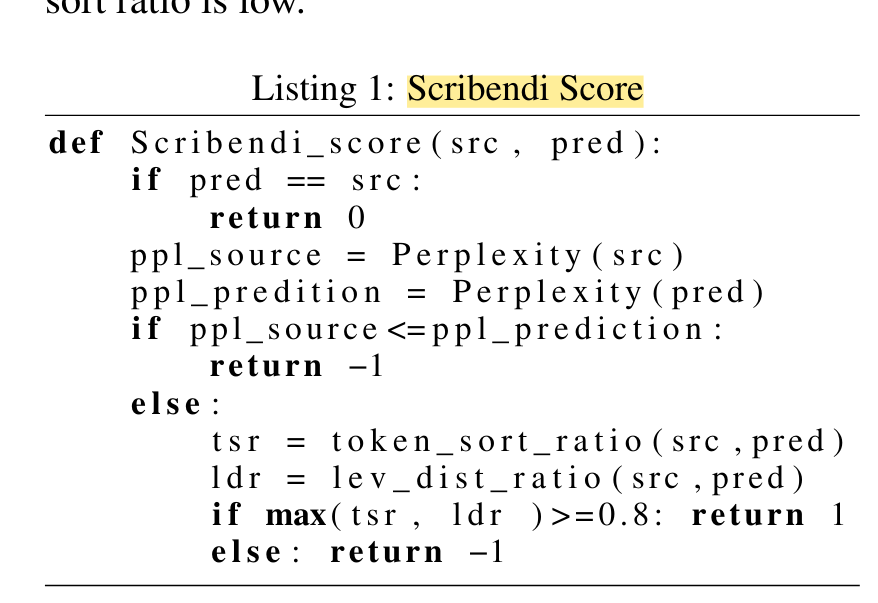

In [14]:
import numpy as np
import evaluate
import Levenshtein
from rapidfuzz import fuzz
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

DEBUG = True

#rewrite for BATCH processing. 
class Scribendi_Batch_Scorer:

    def __init__(self, src_batch, pred_batch):
        assert type(src_batch) == list
        assert type(pred_batch) == list
        assert len(src_batch) == len(pred_batch)

        self.src_batch = src_batch
        self.pred_batch = pred_batch
        
        # Initialize GPT-2
        model_id = "gpt2"
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)
        self.model = AutoModelForCausalLM.from_pretrained(model_id)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        

    def ppl(self, T):
        # T is a list of strings
        inputs = self.tokenizer(T, return_tensors="pt", padding=True)
        inputs = {k: v.to(self.model.device) for k, v in inputs.items()}
        
        with torch.no_grad():
            #Labels are the input_ids themselves
            outputs = self.model(**inputs, labels=inputs["input_ids"])
            loss = outputs.loss # Cross Entropy Loss
            
        return torch.exp(loss).item()

    def scores(self):
        scores = np.zeros(len(self.src_batch))
        #process batch one pair at a time
        for i, (src,pred) in enumerate(zip(self.src_batch,self.pred_batch)):
    
            tsr, ldr = fuzz.token_sort_ratio(src,pred), Levenshtein.ratio(src,pred)
            perplexity_src, perplexity_hyp = self.ppl(src), self.ppl(pred)
            
            if DEBUG:
                print(f"{i} perplexities: {perplexity_src}, {perplexity_hyp}")
                print(f"{i} LDR & TSR   : {ldr}, {tsr}")
            
            if (max(tsr, ldr) < 0.8) or (perplexity_src <= perplexity_hyp):
                scores[i] = -1
            else:
                scores[i] = 1
                
        return scores

In [ ]:
#run examples from scribendi_score/scribendi.py
src = ["Once the test is done , whether the results should be open to his or her relatives has caused social extensive controversy.", "We can not let it go ."]
pred = ["Once the test is done , whether the results should be open to his or her relatives has caused extensive social controversy.","We cannot let it go ."]
scorer = Scribendi_Batch_Scorer(src, pred)
scorer.scores()

#clearup 
del scorer

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10690.91it/s]


0 perplexities: 176.603271484375, 102.8580551147461
0 LDR & TSR   : 0.943089430894309, 100.0
1 perplexities: 101.83676147460938, 161.21145629882812
1 LDR & TSR   : 0.9767441860465116, 83.72093023255813
